# Análisis del vórtice

Análisis en Python de los campos de velocidad obtenidos con PIVlab.

Se determina primero la posición del centro del vórtice. Como su desplazamiento durante la medición resulta pequeño y no modifica apreciablemente los perfiles radiales de velocidad, para el análisis posterior se utiliza un centro fijo dado por la posición media del núcleo.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from scipy.optimize import least_squares, curve_fit

In [2]:
archivo = r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video3_brillantina_oscura_PIV.mat"

# Calibración espacial
distancia_px = 1541.98
distancia_mm = 147

mm_por_px = distancia_mm / distancia_px

# Intervalo entre frames
dt = 16.687e-3  # s

print("Escala:", mm_por_px, "mm/px")
print("dt:", dt, "s")

Escala: 0.09533197577141078 mm/px
dt: 0.016687 s


## Lectura de los campos PIV

In [3]:
def leer_celda(f, results, frame, columna):
    """
    Lee una celda de resultslist de PIVlab.

    Se transpone porque MATLAB/HDF5 almacena las matrices
    con los índices intercambiados respecto de NumPy.
    """
    ref = results[frame, columna]

    return np.array(
        f[ref]
    ).T

In [4]:
with h5py.File(archivo, "r") as f:

    results = f["resultslist"]

    n_campos = results.shape[0]

    # Grilla espacial
    x = leer_celda(f, results, 0, 0)
    y = leer_celda(f, results, 0, 1)

    campos_u = []
    campos_v = []

    for i in range(n_campos):

        campos_u.append(
            leer_celda(f, results, i, 6)
        )

        campos_v.append(
            leer_celda(f, results, i, 7)
        )


u = np.stack(campos_u)
v = np.stack(campos_v)

print("Número de campos:", n_campos)
print("Grilla:", x.shape)
print("u:", u.shape)
print("v:", v.shape)

Número de campos: 663
Grilla: (30, 31)
u: (663, 30, 31)
v: (663, 30, 31)


## Determinación del centro del vórtice

El centro se obtiene buscando el punto respecto del cual el campo de velocidades es, en promedio, lo más tangencial posible.

Para reducir la influencia de vectores poco confiables se descartan las velocidades de menor módulo y se utiliza una región anular alrededor del núcleo.

In [5]:
def encontrar_centro(
    x,
    y,
    U,
    V,
    centro_aprox=None,
    rmin=75,
    rmax=250
):

    velocidad = np.sqrt(
        U**2 + V**2
    )

    validos = (
        np.isfinite(U)
        & np.isfinite(V)
        & np.isfinite(x)
        & np.isfinite(y)
    )

    # Descartamos el 20 % de menor velocidad
    limite = np.nanpercentile(
        velocidad[validos],
        20
    )

    usar = (
        validos
        & (velocidad > limite)
    )


    # Estimación lineal inicial
    if centro_aprox is None:

        A = np.column_stack([
            U[usar],
            V[usar]
        ])

        b = (
            U[usar] * x[usar]
            + V[usar] * y[usar]
        )

        centro_aprox, _, _, _ = np.linalg.lstsq(
            A,
            b,
            rcond=None
        )


    # Selección de una corona
    xc0, yc0 = centro_aprox

    r0 = np.sqrt(
        (x - xc0)**2
        + (y - yc0)**2
    )

    usar &= (
        (r0 > rmin)
        & (r0 < rmax)
    )


    X = x[usar]
    Y = y[usar]

    UU = U[usar]
    VV = V[usar]

    M = velocidad[usar]


    # Componente radial normalizada
    def residuos(centro):

        xc, yc = centro

        dx = X - xc
        dy = Y - yc

        r = np.sqrt(
            dx**2 + dy**2
        )

        return (
            dx * UU + dy * VV
        ) / (r * M)


    resultado = least_squares(
        residuos,
        x0=centro_aprox,
        loss="soft_l1"
    )

    return resultado.x

In [6]:
centros = np.zeros(
    (n_campos, 2)
)

centro_anterior = None

for i in range(n_campos):

    # Mediana de tres campos consecutivos
    i0 = max(0, i - 1)
    i1 = min(n_campos, i + 2)

    U = np.nanmedian(
        u[i0:i1],
        axis=0
    )

    V = np.nanmedian(
        v[i0:i1],
        axis=0
    )

    centros[i] = encontrar_centro(
        x,
        y,
        U,
        V,
        centro_aprox=centro_anterior
    )

    centro_anterior = centros[i]


xc_t = centros[:, 0]
yc_t = centros[:, 1]

xc_fijo = np.mean(xc_t)
yc_fijo = np.mean(yc_t)

print("Centro fijo:")
print("xc =", xc_fijo, "px")
print("yc =", yc_fijo, "px")

Centro fijo:
xc = 611.0720929850727 px
yc = 953.0659984755439 px


In [7]:
desplazamiento = np.sqrt(
    (xc_t - xc_fijo)**2
    + (yc_t - yc_fijo)**2
)

print(
    "Desplazamiento medio:",
    np.mean(desplazamiento) * mm_por_px,
    "mm"
)

print(
    "Desplazamiento máximo:",
    np.max(desplazamiento) * mm_por_px,
    "mm"
)

Desplazamiento medio: 0.7626777265749802 mm
Desplazamiento máximo: 1.8317915442553658 mm


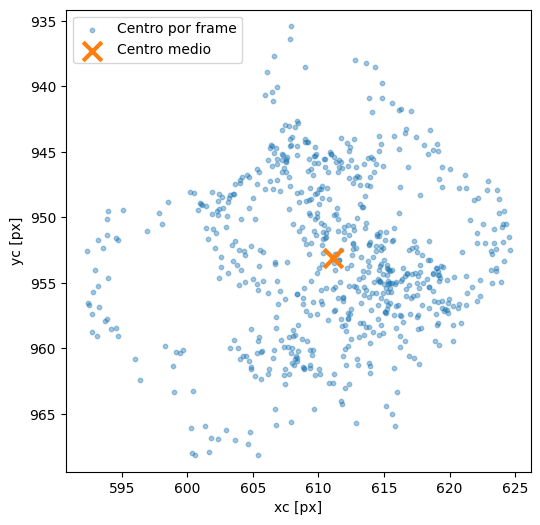

In [8]:
plt.figure(figsize=(6, 6))

plt.scatter(
    xc_t,
    yc_t,
    s=10,
    alpha=0.4,
    label="Centro por frame"
)

plt.scatter(
    xc_fijo,
    yc_fijo,
    marker="x",
    s=180,
    linewidths=3,
    label="Centro medio"
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.xlabel("xc [px]")
plt.ylabel("yc [px]")

plt.legend()
plt.show()

## Velocidades radial y tangencial

In [9]:
def componentes_polares(
    x,
    y,
    U,
    V,
    xc,
    yc,
    mm_por_px,
    dt
):

    # Coordenadas relativas al centro
    dx = x - xc

    # En imágenes y aumenta hacia abajo;
    # para la física tomamos y hacia arriba.
    dy = -(y - yc)

    r_px = np.sqrt(
        dx**2 + dy**2
    )

    r_mm = (
        r_px * mm_por_px
    )

    # Velocidades físicas
    ux = (
        U * mm_por_px / dt
    )

    uy = (
        -V * mm_por_px / dt
    )


    # Versor radial
    er_x = np.divide(
        dx,
        r_px,
        out=np.full_like(dx, np.nan),
        where=r_px > 0
    )

    er_y = np.divide(
        dy,
        r_px,
        out=np.full_like(dy, np.nan),
        where=r_px > 0
    )


    # Versor tangencial
    et_x = -er_y
    et_y = er_x


    # Proyecciones
    vr = (
        ux * er_x
        + uy * er_y
    )

    vtheta = (
        ux * et_x
        + uy * et_y
    )

    return r_mm, vr, vtheta

Promedio radial

In [10]:
dr = 1.0  # mm ESTE ES EL ANCHO DE LOS RADIOSSSSSSSSSS

r_max = 0.45 * distancia_mm

bins = np.arange(
    0,
    r_max + dr,
    dr
)

r_centros = 0.5 * (
    bins[:-1] + bins[1:]
)

In [11]:
def perfil_radial(
    r,
    valor,
    bins
):

    perfil = np.full(
        len(bins) - 1,
        np.nan
    )

    for k in range(
        len(bins) - 1
    ):

        dentro = (
            (r >= bins[k])
            & (r < bins[k + 1])
            & np.isfinite(valor)
        )

        if np.any(dentro):

            perfil[k] = np.mean(
                valor[dentro]
            )

    return perfil

Promedio espacial + temporal usando SOLO centro fijo

In [12]:
perfiles_theta = []
perfiles_r = []

for i in range(n_campos):

    r, vr, vtheta = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_fijo,
        yc_fijo,
        mm_por_px,
        dt
    )

    perfiles_theta.append(
        perfil_radial(
            r,
            vtheta,
            bins
        )
    )

    perfiles_r.append(
        perfil_radial(
            r,
            vr,
            bins
        )
    )


perfiles_theta = np.array(
    perfiles_theta
)

perfiles_r = np.array(
    perfiles_r
)

In [13]:
def promedio_temporal(perfiles):

    cantidad = np.sum(
        np.isfinite(perfiles),
        axis=0
    )

    suma = np.nansum(
        perfiles,
        axis=0
    )

    return np.divide(
        suma,
        cantidad,
        out=np.full(
            suma.shape,
            np.nan,
            dtype=float
        ),
        where=cantidad > 0
    )


vtheta_exp = promedio_temporal(
    perfiles_theta
)

vr_exp = promedio_temporal(
    perfiles_r
)

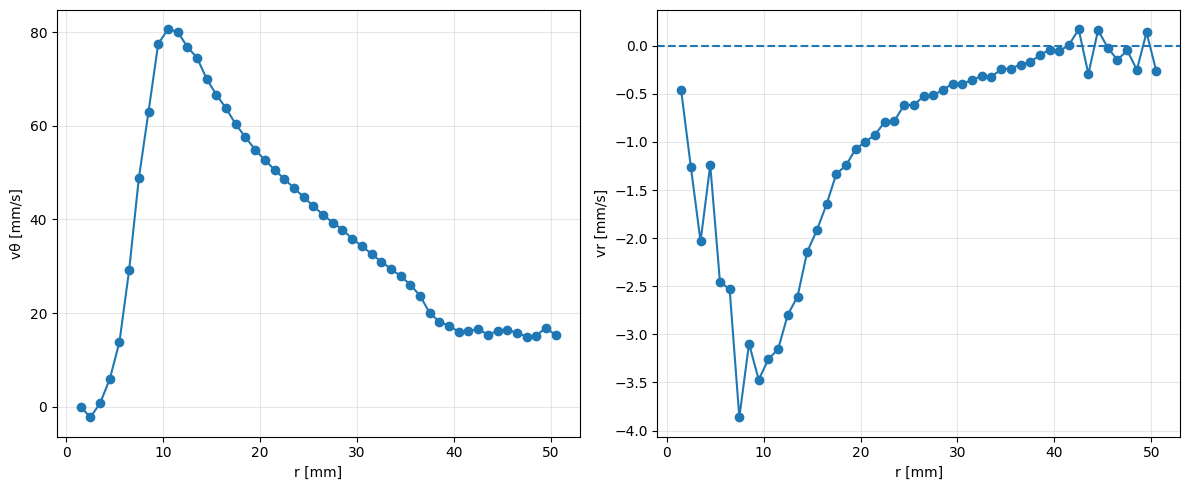

In [14]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ax[0].plot(
    r_centros,
    vtheta_exp,
    "o-"
)

ax[0].set_xlabel("r [mm]")
ax[0].set_ylabel("vθ [mm/s]")
ax[0].grid(alpha=0.3)


ax[1].plot(
    r_centros,
    vr_exp,
    "o-"
)

ax[1].axhline(
    0,
    linestyle="--"
)

ax[1].set_xlabel("r [mm]")
ax[1].set_ylabel("vr [mm/s]")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Ajuste con los modelos de Rankine y Burgers

In [15]:
def rankine_theta(r, C, c):

    r = np.asarray(
        r,
        dtype=float
    )

    return np.where(
        r < c,
        C * r / c**2,
        C / r
    )


def rankine_r(r):

    return np.zeros_like(
        np.asarray(
            r,
            dtype=float
        )
    )


def burgers_theta(r, C, c):

    r = np.asarray(
        r,
        dtype=float
    )

    return (
        C / r
        * (
            1
            - np.exp(
                -r**2 / c**2
            )
        )
    )


def burgers_r(r, c, nu):

    r = np.asarray(
        r,
        dtype=float
    )

    return (
        -2
        * nu
        * r
        / c**2
    )

## Ajuste

Región de ajuste: 2.0 - 40.0 mm
Número de puntos: 38

RANKINE
C = 1056.91 ± 5.11 mm²/s
c = 12.17 ± 0.14 mm
chi² reducido = 4.555

BURGERS
C = 1079.49 ± 6.03 mm²/s
c = 9.20 ± 0.17 mm
chi² reducido = 6.471


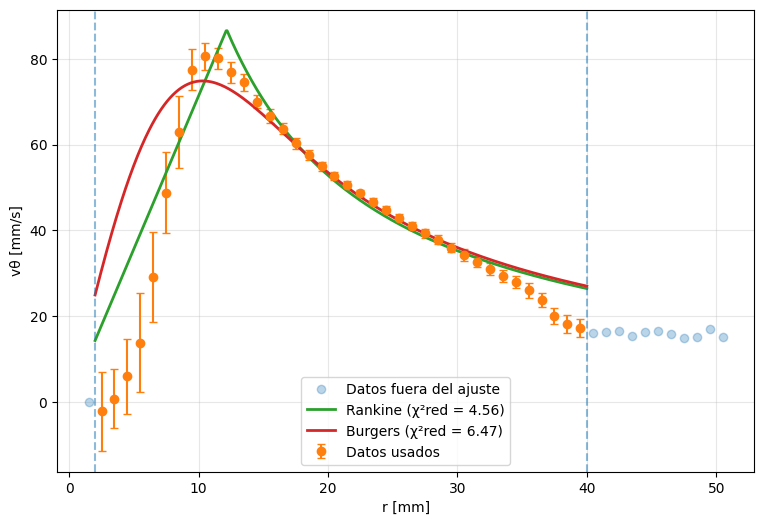

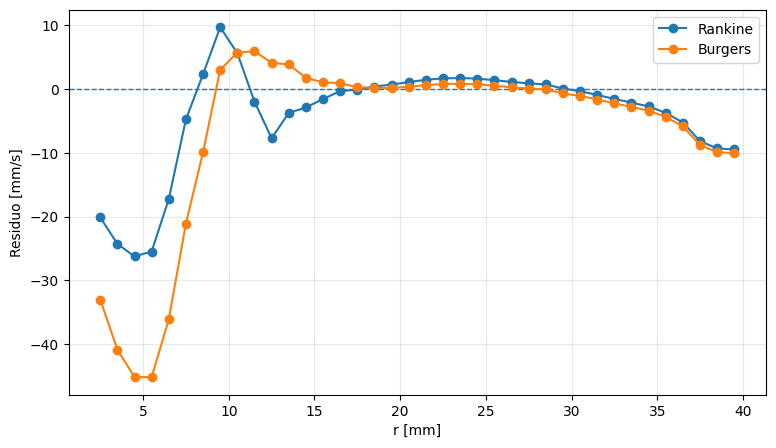

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# PARÁMETROS A MODIFICAR
# ============================================================

# Región radial usada en el ajuste
r_fit_min = 2.0       # mm
r_fit_max = 40.0      # mm

# Bounds para C [mm²/s]
C_min = 0.0
C_max = 2500.0

# Bounds para c [mm]
c_min = 2.0
c_max = 25.0


# ============================================================
# MODELOS
# ============================================================

def rankine(r, C, c):

    r = np.asarray(r, dtype=float)

    return np.where(
        r < c,
        C * r / c**2,
        C / r
    )


def burgers(r, C, c):

    r = np.asarray(r, dtype=float)

    return (
        C / r
        * (1 - np.exp(-r**2 / c**2))
    )


# ============================================================
# DISPERSIÓN TEMPORAL
# ============================================================

# La usamos como sigma para ponderar los puntos
sigma_theta = np.nanstd(
    perfiles_theta,
    axis=0,
    ddof=1
)


# ============================================================
# DATOS USADOS EN EL AJUSTE
# ============================================================

usar = (
    np.isfinite(r_centros)
    & np.isfinite(vtheta_exp)
    & np.isfinite(sigma_theta)
    & (sigma_theta > 0)
    & (r_centros >= r_fit_min)
    & (r_centros <= r_fit_max)
)

r_fit = r_centros[usar]
v_fit = vtheta_exp[usar]
sigma_fit = sigma_theta[usar]


print(
    f"Región de ajuste: "
    f"{r_fit_min:.1f} - {r_fit_max:.1f} mm"
)

print(
    "Número de puntos:",
    len(r_fit)
)


# ============================================================
# ESTIMACIONES INICIALES
# ============================================================

i_max = np.argmax(v_fit)

r_pico = r_fit[i_max]
v_pico = v_fit[i_max]

C0 = v_pico * r_pico

c0_rankine = r_pico

# En Burgers el máximo está aproximadamente en r ≈ 1.12 c
c0_burgers = r_pico / 1.12


# ============================================================
# AJUSTE RANKINE
# ============================================================

popt_rankine, pcov_rankine = curve_fit(
    rankine,
    r_fit,
    v_fit,
    p0=[C0, c0_rankine],
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=(
        [C_min, c_min],
        [C_max, c_max]
    ),
    maxfev=20000
)

C_rankine, c_rankine = popt_rankine


# ============================================================
# AJUSTE BURGERS
# ============================================================

popt_burgers, pcov_burgers = curve_fit(
    burgers,
    r_fit,
    v_fit,
    p0=[C0, c0_burgers],
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=(
        [C_min, c_min],
        [C_max, c_max]
    ),
    maxfev=20000
)

C_burgers, c_burgers = popt_burgers


# ============================================================
# INCERTIDUMBRE DE LOS PARÁMETROS
# ============================================================

err_C_rankine, err_c_rankine = np.sqrt(
    np.diag(pcov_rankine)
)

err_C_burgers, err_c_burgers = np.sqrt(
    np.diag(pcov_burgers)
)


# ============================================================
# RESIDUOS
# ============================================================

pred_rankine = rankine(
    r_fit,
    C_rankine,
    c_rankine
)

pred_burgers = burgers(
    r_fit,
    C_burgers,
    c_burgers
)

res_rankine = v_fit - pred_rankine
res_burgers = v_fit - pred_burgers


# ============================================================
# CHI² REDUCIDO
# ============================================================

chi2_rankine = np.sum(
    (res_rankine / sigma_fit)**2
)

chi2_burgers = np.sum(
    (res_burgers / sigma_fit)**2
)

# Cada modelo tiene 2 parámetros: C y c
grados_libertad = len(r_fit) - 2

chi2red_rankine = (
    chi2_rankine / grados_libertad
)

chi2red_burgers = (
    chi2_burgers / grados_libertad
)


# ============================================================
# RESULTADOS
# ============================================================

print()
print("RANKINE")
print(
    f"C = {C_rankine:.2f} ± "
    f"{err_C_rankine:.2f} mm²/s"
)

print(
    f"c = {c_rankine:.2f} ± "
    f"{err_c_rankine:.2f} mm"
)

print(
    f"chi² reducido = "
    f"{chi2red_rankine:.3f}"
)


print()

print("BURGERS")
print(
    f"C = {C_burgers:.2f} ± "
    f"{err_C_burgers:.2f} mm²/s"
)

print(
    f"c = {c_burgers:.2f} ± "
    f"{err_c_burgers:.2f} mm"
)

print(
    f"chi² reducido = "
    f"{chi2red_burgers:.3f}"
)


# ============================================================
# GRÁFICO DE LOS AJUSTES
# ============================================================

r_modelo = np.linspace(
    r_fit_min,
    r_fit_max,
    500
)

fuera = (
    np.isfinite(r_centros)
    & np.isfinite(vtheta_exp)
    & (
        (r_centros < r_fit_min)
        | (r_centros > r_fit_max)
    )
)


plt.figure(figsize=(9, 6))


# Datos fuera del ajuste
plt.plot(
    r_centros[fuera],
    vtheta_exp[fuera],
    "o",
    alpha=0.3,
    label="Datos fuera del ajuste"
)


# Datos usados
plt.errorbar(
    r_fit,
    v_fit,
    yerr=sigma_fit,
    fmt="o",
    capsize=3,
    label="Datos usados"
)


# Rankine
plt.plot(
    r_modelo,
    rankine(
        r_modelo,
        C_rankine,
        c_rankine
    ),
    linewidth=2,
    label=(
        "Rankine "
        f"(χ²red = {chi2red_rankine:.2f})"
    )
)


# Burgers
plt.plot(
    r_modelo,
    burgers(
        r_modelo,
        C_burgers,
        c_burgers
    ),
    linewidth=2,
    label=(
        "Burgers "
        f"(χ²red = {chi2red_burgers:.2f})"
    )
)


plt.axvline(
    r_fit_min,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    r_fit_max,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("r [mm]")
plt.ylabel("vθ [mm/s]")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


# ============================================================
# GRÁFICO DE RESIDUOS
# ============================================================

plt.figure(figsize=(9, 5))

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.plot(
    r_fit,
    res_rankine,
    "o-",
    label="Rankine"
)

plt.plot(
    r_fit,
    res_burgers,
    "o-",
    label="Burgers"
)

plt.xlabel("r [mm]")
plt.ylabel("Residuo [mm/s]")

plt.grid(alpha=0.3)
plt.legend()

plt.show()